## Projeto: análise e previsão do NPS

**Membros do Grupo:** Amanda Alves, Fabio Costa, Gabriel Victor, Vanessa Partala

**Etapas do CRISP-DM:** compreensão, preparação e análise dos dados  
**Arquivo de entrada:** `data/desafio_nps_fase_1.csv`  
**Arquivo de saída:** `data/processed/nps_tratado.csv` e `data/processed/nps_registros_rejeitados.csv`

---
# BLOCO 01 - CONTEXTO E PREPARAÇÃO

## Contexto

A empresa possui informações sobre clientes, pedidos, entregas, atendimento e
satisfação. Antes da análise exploratória e da modelagem, precisamos verificar se
os dados estão completos, consistentes e adequados ao objetivo do projeto.

Este notebook foi organizado para que outras pessoas consigam acompanhar o
processo, entender as decisões tomadas e reproduzir os resultados.

## Objetivos

- Compreender a estrutura e a unidade de análise da base;
- Verificar valores ausentes, duplicidades e tipos de dados;
- Avaliar a coerência dos valores;
- Investigar possíveis outliers;
- Padronizar nomes e categorias;
- Criar variáveis derivadas úteis para a EDA e o modelo;
- Classificar o NPS em Detrator, Neutro e Promotor;
- Salvar a base tratada em `data/processed/nps_tratado.csv`.

## 1. Preparação do ambiente

Importamos apenas as bibliotecas necessárias para leitura, tratamento,
visualização e exportação dos dados.

In [33]:
# Manipulação e análise de dados
import pandas as pd

# Operações numéricas e criação de condições
import numpy as np

# Criação de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Criação da pasta de saída
import os

## 2. Carregamento da base

A base original será carregada da pasta `data`.

O tratamento será realizado em uma cópia chamada `df`. Assim, o DataFrame
`df_original` permanece disponível para comparação ao final do processo.

In [34]:
# Caminho do arquivo de entrada, considerando o notebook dentro de notebooks/
caminho_entrada = "../data/desafio_nps_fase_1.csv"

# Leitura da base original
df_original = pd.read_csv(caminho_entrada)

# Cópia utilizada durante o tratamento
df = df_original.copy()

# Dimensão inicial da base
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 2500
Quantidade de colunas: 19


### Resultado observado

A base foi carregada com **2.500 registros e 19 colunas**.

Cada linha reúne dados de um cliente e de um pedido. Como `order_id` identifica
a transação registrada, a unidade de análise adotada neste projeto é o **pedido**.

## 3. Reconhecimento da estrutura dos dados

Antes de alterar a base, observamos:

- As primeiras linhas;
- Os nomes das colunas;
- Os tipos armazenados;
- A quantidade de valores preenchidos;
- As estatísticas descritivas das variáveis numéricas.

In [35]:
# Visualização das primeiras linhas
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [36]:
# Lista de colunas disponíveis
df.columns.tolist()

['customer_id',
 'customer_age',
 'customer_region',
 'customer_tenure_months',
 'order_id',
 'order_value',
 'items_quantity',
 'discount_value',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'freight_value',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'repeat_purchase_30d',
 'complaints_count',
 'csat_internal_score']

In [37]:
# Tipos das colunas e quantidade de valores não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [38]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.0,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00


### Resultado observado

A base contém:

- 13 colunas do tipo inteiro;
- 5 colunas do tipo decimal;
- 1 coluna categórica, `customer_region`.

Os valores de `customer_age` variam de **18 a 69 anos**, `nps_score` varia de
**0 a 10** e as variáveis financeiras estão armazenadas como números decimais.

Nesta versão da base, os tipos carregados são coerentes com o significado das
variáveis. Por isso, não será feita conversão automática de tipos.

## BLOCO 2 — Qualidade dos dados

## 1. Diagnóstico inicial de qualidade

O diagnóstico reúne três informações por coluna:

- Tipo de dado;
- Quantidade de valores ausentes;
- Quantidade de valores únicos.

Essa visão permite identificar rapidamente colunas que exigem investigação.

In [39]:
# Diagnóstico simples por coluna
diagnostico = pd.DataFrame({
    "tipos_dados": df.dtypes.astype(str),
    "quantidade_nulos": df.isnull().sum(),
    "valores_unicos": df.nunique(dropna=False)
})

diagnostico

,tipos_dados,quantidade_nulos,valores_unicos
customer_id,int64,0,2500
customer_age,int64,0,52
customer_region,object,0,5
customer_tenure_months,int64,0,119
order_id,int64,0,2500
order_value,float64,0,2457
items_quantity,int64,0,6
discount_value,float64,0,2050
payment_installments,int64,0,11
delivery_time_days,int64,0,13


### Resultado observado

O diagnóstico confirma que:

- Nenhuma coluna possui valores ausentes;
- `customer_id` e `order_id` possuem 2.500 valores únicos;
- `customer_region` possui 5 categorias;
- `repeat_purchase_30d` possui 2 valores possíveis;
- `nps_score` possui 101 valores diferentes, pois a base contém notas decimais.

Esses resultados serão detalhados nas próximas etapas.

## 2. Verificação de registros duplicados

São verificadas três situações:

1. Linhas completamente iguais;
2. `order_id` repetido;
3. `customer_id` repetido.

A verificação separada é importante porque identificadores diferentes representam
conceitos diferentes.

In [40]:
print("=" * 32)
print("Análise de registros duplicados")
print("=" * 32)


# Linhas completamente iguais
linhas_duplicadas = df.duplicated().sum()

# Identificadores de pedido repetidos
pedidos_duplicados = df["order_id"].duplicated().sum()

# Identificadores de cliente repetidos
clientes_duplicados = df["customer_id"].duplicated().sum()

print(f"Linhas completamente duplicadas: {linhas_duplicadas}")
print(f"order_id duplicados: {pedidos_duplicados}")
print(f"customer_id duplicados: {clientes_duplicados}")

Análise de registros duplicados
Linhas completamente duplicadas: 0
order_id duplicados: 0
customer_id duplicados: 0


## 3. Validação de regras de qualidade

Além dos tipos de dados, foram avaliadas regras de coerência relacionadas ao
significado de cada coluna.

As regras foram separadas em dois níveis:

- **Regra crítica:** indica uma relação incompatível com a definição das colunas.
  O registro é separado da base principal e mantido em um arquivo de auditoria;
- **Regra de atenção:** indica uma situação incomum, mas possível. O registro é
  mantido e recebe um indicador para investigação na EDA.

Essa abordagem evita corrigir valores sem evidência e mantém rastreabilidade sobre
as decisões adotadas.

In [41]:
print("=" * 25)
print("   Validação de regras")
print("=" * 25)

# Regras básicas de validação
regras_validacao = {
    "Idade menor que zero": df["customer_age"] < 0,
    "Idade maior que 120": df["customer_age"] > 120,
    "Tempo de relacionamento negativo": df["customer_tenure_months"] < 0,
    "Valor do pedido negativo": df["order_value"] < 0,
    "Quantidade de itens menor ou igual a zero": df["items_quantity"] <= 0,
    "Desconto negativo": df["discount_value"] < 0,
    "Tempo de entrega menor ou igual a zero": df["delivery_time_days"] <= 0,
    "Dias de atraso negativos": df["delivery_delay_days"] < 0,
    "Frete negativo": df["freight_value"] < 0,
    "Contatos com atendimento negativos": df["customer_service_contacts"] < 0,
    "Tempo de resolução negativo": df["resolution_time_days"] < 0,
    "NPS fora da escala de 0 a 10": ~df["nps_score"].between(0, 10),
    "Recompra fora das categorias 0 e 1": ~df["repeat_purchase_30d"].isin([0, 1]),
    "Quantidade de reclamações negativa": df["complaints_count"] < 0,
    "Frete menor que 0": df["freight_value"] <0
}

# Regras específicas relacionadas ao pedido e à entrega
regras_contexto = {
    "Atraso maior ou igual que o tempo total de entrega":
        df["delivery_delay_days"] >= df["delivery_time_days"],

    "Desconto maior que o valor do pedido":
        df["discount_value"] > df["order_value"],

    "Frete maior que o valor do pedido":
        df["freight_value"] > df["order_value"],
}

# Contagem de registros em cada regra
validacao_regras = pd.DataFrame({
    "quantidade": {
        **{nome: condicao.sum() for nome, condicao in regras_validacao.items()},
        **{nome: condicao.sum() for nome, condicao in regras_contexto.items()},
    }
})

validacao_regras["percentual"] = (
    validacao_regras["quantidade"] / len(df) * 100
).round(2)

validacao_regras

   Validação de regras


,quantidade,percentual
Idade menor que zero,0,0.00
Idade maior que 120,0,0.00
Tempo de relacionamento negativo,0,0.00
Valor do pedido negativo,0,0.00
Quantidade de itens menor ou igual a zero,0,0.00
Desconto negativo,0,0.00
Tempo de entrega menor ou igual a zero,0,0.00
Dias de atraso negativos,0,0.00
Frete negativo,0,0.00
Contatos com atendimento negativos,0,0.00


### Resultado observado

As regras básicas de domínio não identificaram valores negativos, idades fora do
intervalo adotado, NPS fora da escala ou categorias inválidas de recompra.

Entretanto, foram encontradas três situações que exigem avaliação específica:

- **267 registros** com atraso maior ou igual que o tempo total de entrega;
- **35 registros** com desconto maior que o valor do pedido;
- **18 registros** com frete maior que o valor do pedido.

## 4. Padronização dos nomes das colunas

Os nomes já estavam próximos de um padrão consistente. Mesmo assim, aplicamos
uma padronização simples para evitar espaços ou diferenças entre letras maiúsculas
e minúsculas.

O padrão adotado utiliza:

- Letras minúsculas;
- Remoção de espaços no início e no final;
- Sublinhado no lugar de espaços internos.

In [42]:
# Padronização dos nomes das colunas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Conferência após a padronização
df.columns.tolist()

['customer_id',
 'customer_age',
 'customer_region',
 'customer_tenure_months',
 'order_id',
 'order_value',
 'items_quantity',
 'discount_value',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'freight_value',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'repeat_purchase_30d',
 'complaints_count',
 'csat_internal_score']

**4.1 Padronização de `customer_region`**

Categorias com diferenças de espaços ou grafia podem ser interpretadas como categorias distintas, por isso aplicamos uma padronização simples.

In [43]:
# Remove espaços, converte temporariamente para letras minúsculas e substitui pelas grafias definidas para o projeto.
df["customer_region"] = (
    df["customer_region"]
    .str.strip()
    .str.lower()
    .replace({
        "norte": "Norte",
        "nordeste": "Nordeste",
        "centro-oeste": "Centro-Oeste",
        "centro oeste": "Centro-Oeste",
        "sudeste": "Sudeste",
        "sul": "Sul"
    })
)

# Distribuição após a padronização
regioes_depois = df["customer_region"].value_counts(dropna=False)

regioes_depois

customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64

# BLOCO 03 - TRATAMENTO

Depois serão criadas as variáveis:

- `had_delivery_delay`
- `had_customer_service_contact `
- `had_complaint`
- `delivery_delay_ratio`
- `age_range`
- `customer_tenure_range`
- `order_value_range`
- `delivery_time_range`
- `complaints_range`
- `nps_class`
- `perc_discount_range`
- `delay_range`


## 1. Tratamento das regras de qualidade

Nesta etapa serão aplicadas as decisões definidas para:

- Atraso maior que o tempo total de entrega;
- Desconto maior que o valor do pedido;
- Frete maior que o valor do pedido.

A base original continuará preservada em `df_original`.

### 1.1 - Indicadores operacionais

**Indicador de atraso**

A variável `had_delivery_delay` foi criada para identificar se o pedido apresentou pelo
menos um dia de atraso na entrega.

A classificação utilizada foi:

- `0`: pedido sem atraso;
- `1`: pedido com atraso.

In [44]:
# Cria o indicador binário de atraso
df["had_delivery_delay"] = np.where(
    df["delivery_delay_days"] > 0,
    1,
    0
)

# Quantidade e percentual de pedidos em cada situação
resumo_atraso = pd.DataFrame({
    "quantidade": df["had_delivery_delay"].value_counts().sort_index(),
    "percentual": (
        df["had_delivery_delay"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

resumo_atraso

,quantidade,percentual
had_delivery_delay,,
0,277,11.08
1,2223,88.92


**Indicador de contato com o atendimento**

A variável `had_customer_service_contact` foi criada para identificar se o cliente
precisou entrar em contato com a equipe de atendimento.

A classificação utilizada foi:

- `0`: nenhum contato registrado;
- `1`: pelo menos um contato registrado.

In [45]:
# Cria o indicador binário de atendimento
df["had_customer_service_contact"] = np.where(
    df["customer_service_contacts"] > 0,
    1,
    0
)

# Quantidade e percentual de pedidos em cada situação
resumo_atendimento = pd.DataFrame({
    "quantidade": df["had_customer_service_contact"].value_counts().sort_index(),
    "percentual": (
        df["had_customer_service_contact"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

resumo_atendimento

,quantidade,percentual
had_customer_service_contact,,
0,554,22.16
1,1946,77.84


**Indicador de reclamação**

A variável `had_complaint` foi criada para identificar se existe pelo menos uma
reclamação registrada para o pedido.

A classificação utilizada foi:

- `0`: nenhuma reclamação registrada;
- `1`: uma ou mais reclamações registradas.

In [46]:
# Cria o indicador binário de reclamação
df["had_complaint"] = np.where(
    df["complaints_count"] > 0,
    1,
    0
)

# Quantidade e percentual de pedidos em cada situação
resumo_reclamacao = pd.DataFrame({
    "quantidade": df["had_complaint"].value_counts().sort_index(),
    "percentual": (
        df["had_complaint"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

resumo_reclamacao

,quantidade,percentual
had_complaint,,
0,23,0.92
1,2477,99.08


### Síntese dos indicadores operacionais

Os três indicadores criados apresentam alta concentração na categoria `1`:

| Indicador | Quantidade com ocorrência | Percentual |
|---|---:|---:|
| Pedido com atraso | 2.223 | 88,92% |
| Contato com atendimento | 1.946 | 77,84% |
| Pedido com reclamação | 2.477 | 99,08% |

Os resultados mostram que atraso, atendimento e reclamação são eventos frequentes
na base analisada.

Entretanto, as frequências não demonstram que esses fatores causam redução no
NPS. Elas apenas orientam as hipóteses que deverão ser investigadas na EDA.

Também será necessário considerar que os grupos são desbalanceados, principalmente
no indicador de reclamação. Por isso, as variáveis numéricas originais devem ser
preservadas:

- `delivery_delay_days`;
- `customer_service_contacts`;
- `complaints_count`.

Essas colunas permitem análises mais detalhadas do que os indicadores binários.

### 1.2 - Regras críticas e registros para auditoria

Foram consideradas críticas as seguintes relações:

1. `delivery_delay_days >= delivery_time_days`

   O atraso não deve superar ou igualar o tempo **total** de entrega, considerando a definição apresentada no dicionário de dados.

2. `discount_value > order_value`

   O desconto não deve superar o valor total do pedido. Como a base não informa outro valor de referência para a compra, não existe informação suficiente para corrigir o registro com segurança.

A prática adotada será a **quarentena de dados**:

- Os registros não serão corrigidos por suposição;
- Eles serão retirados da base principal usada na EDA e na modelagem;
- Serão salvos separadamente com o motivo da inconsistência;
- A base original permanecerá preservada.

In [47]:
# Máscaras das regras críticas
regra_atraso = (df["delivery_delay_days"] >= df["delivery_time_days"])

regra_desconto = (df["discount_value"] > df["order_value"])

mascara_registro_critico = regra_atraso | regra_desconto
# Um registro pode violar uma ou as duas regras. O | diz: "Marca como crítico se violar qualquer uma das regras (ou ambas)


# Resumo antes do tratamento
resumo_regras_criticas = pd.DataFrame({
    "regra": [
        "Atraso maior que o tempo total de entrega",
        "Desconto maior que o valor do pedido",
        "Pelo menos uma regra crítica"
    ],
    "quantidade": [
        regra_atraso.sum(),
        regra_desconto.sum(),
        mascara_registro_critico.sum()
    ]
})

resumo_regras_criticas["percentual"] = (
    resumo_regras_criticas["quantidade"] / len(df) * 100
).round(1)

resumo_regras_criticas

,regra,quantidade,percentual
0,Atraso maior que o tempo total de entrega,267,10.7
1,Desconto maior que o valor do pedido,35,1.4
2,Pelo menos uma regra crítica,298,11.9


**Identificação do motivo da inconsistência**

Os registros críticos serão mantidos em uma base separada.

A coluna `inconsistency_reason` informa qual regra foi violada. Quando o mesmo
pedido viola as duas regras, os dois motivos são registrados.

Esse arquivo permite revisar os casos posteriormente sem misturá-los à base
principal.

In [48]:
# Seleciona os registros que violam pelo menos uma regra crítica
df_registros_rejeitados = df.loc[mascara_registro_critico].copy()

# Registra o motivo de cada inconsistência
df_registros_rejeitados["inconsistency_reason"] = ""
# Cria coluna vazia inconsistency_reason

def registrar_inconsistencia(regra):
    motivos = []

    if regra_atraso[regra]:
        motivos.append("atraso_maior_que_tempo_entrega")

    if regra_desconto[regra]:
        motivos.append("desconto_maior_que_pedido")

    return "; ".join(motivos)

df_registros_rejeitados["inconsistency_reason"] = (
    df_registros_rejeitados.index.map(registrar_inconsistencia)
)

print(f"Registros separados para auditoria: {len(df_registros_rejeitados)}")

df_registros_rejeitados[
    [
        "order_id",
        "order_value",
        "discount_value",
        "delivery_time_days",
        "delivery_delay_days",
        "inconsistency_reason"
    ]
].head(10)

Registros separados para auditoria: 298


,order_id,order_value,discount_value,delivery_time_days,delivery_delay_days,inconsistency_reason
0,50001,139.73,39.35,2,2,atraso_maior_que_tempo_entrega
5,50006,568.76,36.58,4,5,atraso_maior_que_tempo_entrega
6,50007,41.29,99.62,8,3,desconto_maior_que_pedido
18,50019,383.98,33.61,3,4,atraso_maior_que_tempo_entrega
21,50022,480.03,14.53,4,4,atraso_maior_que_tempo_entrega
23,50024,489.49,8.44,3,3,atraso_maior_que_tempo_entrega
41,50042,117.97,28.35,2,3,atraso_maior_que_tempo_entrega
46,50047,461.42,27.91,4,6,atraso_maior_que_tempo_entrega
54,50055,398.94,5.22,2,2,atraso_maior_que_tempo_entrega
57,50058,86.15,112.42,10,3,desconto_maior_que_pedido


In [49]:
# Mantém na base principal somente os registros aprovados
df = df.loc[~mascara_registro_critico].copy()

print(f"Registros da base original: {len(df_original)}")
print(f"Registros separados para auditoria: {len(df_registros_rejeitados)}")
print(f"Registros mantidos na base tratada: {len(df)}")

print(
    "Conferência do total: "
    f"{len(df_registros_rejeitados) + len(df)}"
)

Registros da base original: 2500
Registros separados para auditoria: 298
Registros mantidos na base tratada: 2202
Conferência do total: 2500


### 1.3 -  Frete maior que o valor do pedido

O frete maior que o valor do pedido é uma situação comercialmente incomum, mas não
é uma impossibilidade lógica.

Ela pode ocorrer em pedidos de baixo valor, rotas mais caras ou operações sem
subsídio de frete. Como a base não possui peso, distância, modalidade de entrega ou
regra de cobrança, não há evidência suficiente para classificar esses registros como
erro.

#### Decisão adotada

Os registros serão mantidos e receberão a variável
`freight_exceeds_order_value`:

- `0`: frete menor ou igual ao valor do pedido;
- `1`: frete maior que o valor do pedido.

A variável permitirá verificar na EDA se essa relação está associada a notas menores
de NPS.

In [50]:
# Cria um indicador para pedidos cujo frete supera o valor do pedido
df["freight_exceeds_order_value"] = np.where(
    df["freight_value"] > df["order_value"],
    1,
    0
)

resumo_frete_pedido = pd.DataFrame({
    "quantidade": df["freight_exceeds_order_value"].value_counts(),
    "percentual": (
        df["freight_exceeds_order_value"].value_counts(normalize=True) * 100
    ).round(2)
})

resumo_frete_pedido

,quantidade,percentual
freight_exceeds_order_value,,
0,2195,99.68
1,7,0.32


### 1.4 Atraso percentual

Após a retirada dos registros que violavam a regra crítica de entrega, a variável
`delivery_delay_ratio` pode ser calculada de forma coerente:

`delivery_delay_days / delivery_time_days`

O resultado indica quanto do tempo total de entrega corresponde aos dias de atraso.

In [51]:
# Calcula o atraso proporcional ao tempo total de entrega
df["delivery_delay_ratio"] = (
    df["delivery_delay_days"] / df["delivery_time_days"]
)

# Confere se o resultado está entre 0 e 1
print(
    "Valores acima de 100%: ",
    (df["delivery_delay_ratio"] > 1).sum()
)

df["delivery_delay_ratio"].describe().round(2)

Valores acima de 100%:  0


count    2202.00
mean        0.27
std         0.20
min         0.00
25%         0.12
50%         0.23
75%         0.38
max         0.88
Name: delivery_delay_ratio, dtype: float64

#### Resultado do tratamento

A base principal passa a conter apenas registros que não ferem as duas regras críticas.

O tratamento não tentou adivinhar ou substituir valores. Os registros separados continuam disponíveis em um arquivo de auditoria.

O frete maior que o pedido foi mantido como uma característica observável. Essa decisão preserva uma experiência potencialmente importante para explicar a insatisfação, sem apresentar o caso como erro confirmado.

## 2 - Criação de variáveis - faixas

Faixas de valores para agrupar os registros em variaveis relevantes.

As novas colunas serão usadas para facilitar segmentações e comparações na EDA.

Os intervalos são uma decisão analítica deste projeto, após avaliação da base.

### 2.1 - Faixa etária

In [52]:
# Limites e rótulos das faixas etárias
limites_idade = [0, 24, 34, 44, 54, 64, np.inf]
#np.inf Serve para marcar o limite superior aberto da última faixa.

rotulos_idade = [
    "Até 24 anos",
    "25 a 34 anos",
    "35 a 44 anos",
    "45 a 54 anos",
    "55 a 64 anos",
    "65 anos ou mais"
]

# Criação da coluna faixa etária
df["age_range"] = pd.cut(
    df["customer_age"],
    bins=limites_idade,
    labels=rotulos_idade,
    include_lowest=True
)

# Distribuição das faixas
contagem_faixas = df["age_range"].value_counts(sort=False, dropna=False).to_frame("quantidade")
#calcular percentual
contagem_faixas["percentual"] = (contagem_faixas["quantidade"]/len(df)*100).round(1)

contagem_faixas.reset_index()


,age_range,quantidade,percentual
0,Até 24 anos,307,13.9
1,25 a 34 anos,406,18.4
2,35 a 44 anos,441,20.0
3,45 a 54 anos,427,19.4
4,55 a 64 anos,416,18.9
5,65 anos ou mais,205,9.3


#### Resultado observado

Todos os registros receberam uma faixa etária. A maior faixa é **35 a 44 anos**, com 509 registros (20%). A menor é **65 anos ou mais**, com 238 registros (9,5%). As demais faixas também possuem quantidade suficiente para comparações exploratórias.

### 2.2 - Faixa de tempo de relacionamento

In [53]:
# Limites e rótulos das faixas de relacionamento
limites_tenure = [0, 12, 24, 48, 72, np.inf]

rotulos_tenure = [
    "Até 12 meses",
    "13 a 24 meses",
    "25 a 48 meses",
    "49 a 72 meses",
    "Mais de 72 meses"
]

# Criação da faixa de relacionamento
df["customer_tenure_range"] = pd.cut(
    df["customer_tenure_months"],
    bins=limites_tenure,
    labels=rotulos_tenure,
    include_lowest=True
)

# Distribuição das faixas
tempo_relacionamento = df["customer_tenure_range"].value_counts(sort=False, dropna=False).to_frame("quantidade")
tempo_relacionamento["percentual"] = (tempo_relacionamento["quantidade"]/len(df)*100).round(1)

tempo_relacionamento.reset_index()


,customer_tenure_range,quantidade,percentual
0,Até 12 meses,213,9.7
1,13 a 24 meses,224,10.2
2,25 a 48 meses,413,18.8
3,49 a 72 meses,435,19.8
4,Mais de 72 meses,917,41.6


#### Resultado observado

Todos os registros receberam uma faixa de relacionamento. O maior grupo é **Mais de 72 meses**, com 1.041 registros, que representa 42% da basse. Isso mostra que uma parte relevante da base possui relacionamento mais longo com a empresa.

### 2.3 - Faixa de valor do pedido

In [54]:
limites_order_value = [0, 150, 300, 500, 800, np.inf]

rotulos_order_value = [
    "Até R$150",
    "R$150 a R$300",
    "R$300 a R$500",
    "R$500 a R$800",
    "Acima de R$800"
]

# Criação da faixa de preço
df["order_value_range"] = pd.cut(
    df["order_value"],
    bins=limites_order_value,
    labels=rotulos_order_value,
    include_lowest=True
)

# Distribuição das faixas
valor_pedido = df["order_value_range"].value_counts(sort=False, dropna=False).to_frame("quantidade")
valor_pedido["percentual"] = (valor_pedido["quantidade"]/len(df)*100).round(1)

valor_pedido.reset_index()


,order_value_range,quantidade,percentual
0,Até R$150,276,12.5
1,R$150 a R$300,558,25.3
2,R$300 a R$500,644,29.2
3,R$500 a R$800,484,22.0
4,Acima de R$800,240,10.9


### 2.3 - Faixa de tempo de entrega
Temos que o minimo é 2 e o maximo é 14 dias.

In [55]:
limites_delivery_time = [0, 5, 8, 11, np.inf]

rotulos_delivery_time = [
    "Entrega de 0 a 5 dias",
    "Entrega de 5 a 8 dias",
    "Entrega de 8 a 11 dias",
    "Entrega 11+ dias"
]

# Criação da faixa de tempo de entrega
df["delivery_time_range"] = pd.cut(
    df["delivery_time_days"],
    bins=limites_delivery_time,
    labels=rotulos_delivery_time,
    include_lowest=True
)

# Distribuição das faixas
tempo_entrega = df["delivery_time_range"].value_counts(sort=False, dropna=False).to_frame("quantidade")
tempo_entrega["percentual"] = (tempo_entrega["quantidade"]/len(df)*100).round(1)

tempo_entrega.reset_index()

,delivery_time_range,quantidade,percentual
0,Entrega de 0 a 5 dias,500,22.7
1,Entrega de 5 a 8 dias,556,25.2
2,Entrega de 8 a 11 dias,549,24.9
3,Entrega 11+ dias,597,27.1


### 2.4 Faixa de numero de reclamações

In [56]:
limites_complaints = [0, 2, 4, 6, 12]

rotulos_complaints = [
    "De 0 a 2 Reclamações",
    "De 2 a 4 Reclamações",
    "De 4 a 6 Reclamações",
    "6 ou mais Reclamações"
]

# Criação da faixa de reclamações
df["complaints_range"] = pd.cut(
    df["complaints_count"],
    bins=limites_complaints,
    labels=rotulos_complaints,
    include_lowest=True
)

# Distribuição das faixas
reclamacoes = df["complaints_range"].value_counts(sort=False, dropna=False).to_frame("quantidade")
reclamacoes["percentual"] = (reclamacoes["quantidade"]/len(df)*100).round(1)

reclamacoes.reset_index()

,complaints_range,quantidade,percentual
0,De 0 a 2 Reclamações,390,17.7
1,De 2 a 4 Reclamações,967,43.9
2,De 4 a 6 Reclamações,617,28.0
3,6 ou mais Reclamações,228,10.4


### 2.5 - Classificação do NPS (variável alvo)

A base possui notas decimais entre 0 e 10. Para que todos os valores recebam uma
classe, adotamos intervalos contínuos:

- **Detrator:** nota menor ou igual a 6;
- **Neutro:** nota maior que 6 e menor ou igual a 8;
- **Promotor:** nota maior que 8 e menor ou igual a 10.

Essa é uma adaptação operacional da regra proposta no escopo. A nota original será
preservada.

In [57]:
# Conferência dos limites da variável antes da classificação
print(f"Menor nota de NPS: {df['nps_score'].min()}")
print(f"Maior nota de NPS: {df['nps_score'].max()}")

# Função de classificação do NPS
def classificar_nps(nota):
    if pd.isna(nota):
        return np.nan
    elif nota < 7:
        return "Detrator"
    elif nota < 9:
        return "Neutro"
    else:
        return "Promotor"

# Criação da classe
df["nps_class"] = df["nps_score"].apply(classificar_nps)

# Quantidade e percentual por classe
resumo_classes_nps = pd.DataFrame({
    "quantidade": df["nps_class"].value_counts(),
    "percentual": (
        df["nps_class"].value_counts(normalize=True) * 100
    ).round(1)
})

resumo_classes_nps.reset_index()

Menor nota de NPS: 0.0
Maior nota de NPS: 10.0


,nps_class,quantidade,percentual
0,Detrator,1829,83.1
1,Neutro,267,12.1
2,Promotor,106,4.8


### Resultado observado

A classificação gerou:

- 1.964 Detrator (**83,7**);
- 274 Neutro (**11,7%**);
- 108 Promotor (**4,6%**).

A base apresenta forte concentração na classe Detrator. Esse desbalanceamento
deverá ser considerado na etapa de modelagem, mas o tratamento específico pertence
ao notebook do item 4.

Para as próximas etapas:

- `nps_score` poderá ser utilizado como alvo de regressão;
- `nps_category` poderá ser utilizada como alvo de classificação.

### 2.6 Variável de % de desconto

In [58]:
df["discount_percentage"] = (df["discount_value"] / df["order_value"] * 100).round(1)

limites_discount_pct = [0, 5, 10, 15, 25, np.inf]

rotulos_discount_pct = [
    "Sem/Min Desconto (0-5%)",
    "Desconto Baixo (5-10%)",
    "Desconto Moderado (10-15%)",
    "Desconto Alto (15-25%)",
    "Desconto Excessivo (25%+)"
]

# Criação da faixa de reclamações
df["perc_discount_range"] = pd.cut(
    df["discount_percentage"],
    bins=limites_discount_pct,
    labels=rotulos_discount_pct,
    include_lowest=True
)

# Distribuição das faixas
df_discount_range = df["perc_discount_range"].value_counts(sort=False, dropna=False).to_frame("quantidade")
df_discount_range["percentual"] = (df_discount_range["quantidade"]/len(df)*100).round(1)
df_discount_range.reset_index()


,perc_discount_range,quantidade,percentual
0,Sem/Min Desconto (0-5%),1019,46.3
1,Desconto Baixo (5-10%),495,22.5
2,Desconto Moderado (10-15%),241,10.9
3,Desconto Alto (15-25%),225,10.2
4,Desconto Excessivo (25%+),222,10.1


### 2.7 Variável de % de tempo de atraso

In [59]:
df["delay_percentage"] = (df["delivery_delay_days"] / df["delivery_time_days"] * 100).round(2)
# quantos % de atraso teve na entrega em relação ao total de dias de entrega\

limites_delay_dias = [0, 1, 2, 3, 6, np.inf]

rotulos_delay_dias = [
    "No Prazo (0 dias)",
    "Atraso Leve (1 dia)",
    "Atraso Moderado (2 dias)",
    "Atraso Significativo (3 dias)",
    "Atraso Severo (6+ dias)"
]
# Criação da faixa de reclamações
df["delay_range"] = pd.cut(
    df["delivery_delay_days"],
    bins=limites_delay_dias,
    labels=rotulos_delay_dias,
    include_lowest=True
)

# Distribuição das faixas
df_delay_range = df["delay_range"].value_counts(sort=False, dropna=False).to_frame("quantidade")
df_delay_range["percentual"] = (df_delay_range["quantidade"]/len(df)*100).round(1)
df_delay_range.reset_index()


,delay_range,quantidade,percentual
0,No Prazo (0 dias),879,39.9
1,Atraso Leve (1 dia),572,26.0
2,Atraso Moderado (2 dias),439,19.9
3,Atraso Significativo (3 dias),303,13.8
4,Atraso Severo (6+ dias),9,0.4


In [60]:
df.to_excel("../data/processed/df_avaliacao.xlsx")

## excel intermediário para validar se as novas variaveis estão corretas 

# BLOCO 04 - ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

## Objetivo

Responder às 4 perguntas de negócio sobre o NPS:

1. **Quais fatores parecem mais críticos para a satisfação?**
2. **O que mais gera detratores?**
3. **Existe algum "ponto de ruptura" na experiência do cliente?**
4. **Que tipo de cliente tende a ter NPS mais alto ou mais baixo?**

### 1. Carregamento e Estatísticas Iniciais

In [61]:
# Carregar o arquivo tratado
# df_eda = pd.read_excel('../data/processed/df_avaliacao.xlsx')
df_eda = df.copy()
df_eda = df_eda.drop(columns=['Unnamed: 0'], errors='ignore')

print(f"Shape dos dados: {df_eda.shape}")
print(f"\nDistribuição do NPS:")
print(df_eda['nps_class'].value_counts())
print(f"\nNPS Score:")
print(f"  Mínimo: {df_eda['nps_score'].min()}")
print(f"  Máximo: {df_eda['nps_score'].max()}")
print(f"  Média: {df_eda['nps_score'].mean():.2f}")
print(f"  Mediana: {df_eda['nps_score'].median():.2f}")

Shape dos dados: (2202, 34)

Distribuição do NPS:
nps_class
Detrator    1829
Neutro       267
Promotor     106
Name: count, dtype: int64

NPS Score:
  Mínimo: 0.0
  Máximo: 10.0
  Média: 4.55
  Mediana: 4.60


### 2. PERGUNTA 1: Quais fatores parecem mais críticos para a satisfação?

#### Abordagem:
Analisamos correlações entre variáveis numéricas e NPS Score, além de comparações de NPS médio entre categorias.

#### Hipótese Inicial:
Variáveis relacionadas a entrega, atendimento e satisfação interna devem ter relação com o NPS.

In [62]:
# Análise de Correlações
variaveis_numericas = df_eda.select_dtypes(include=[np.number]).columns.tolist()

variaveis_numericas

['customer_id',
 'customer_age',
 'customer_tenure_months',
 'order_id',
 'order_value',
 'items_quantity',
 'discount_value',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'freight_value',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'repeat_purchase_30d',
 'complaints_count',
 'csat_internal_score',
 'had_delivery_delay',
 'had_customer_service_contact',
 'had_complaint',
 'freight_exceeds_order_value',
 'delivery_delay_ratio',
 'discount_percentage',
 'delay_percentage']

In [63]:
# Análise de Correlações
variaveis_numericas = df_eda.select_dtypes(include=[np.number]).columns.tolist()
correlacoes_nps = df_eda[variaveis_numericas].corr()['nps_score'].sort_values(ascending=False)

print("Top 10 Variáveis com Maior Correlação com NPS Score:")
print("="*60)
for i, (var, corr) in enumerate(correlacoes_nps.drop(['nps_score']).items(), 1):
    print(f"{i:2d}. {var:40s} {corr:7.3f}")
# o enumerate é para trazer o ranking começando do 1 ao inves do padrão 0.

Top 10 Variáveis com Maior Correlação com NPS Score:
 1. repeat_purchase_30d                        0.578
 2. csat_internal_score                        0.548
 3. delivery_attempts                          0.039
 4. order_value                                0.035
 5. payment_installments                       0.021
 6. discount_value                             0.020
 7. customer_id                                0.018
 8. order_id                                   0.018
 9. items_quantity                             0.015
10. discount_percentage                       -0.006
11. customer_tenure_months                    -0.011
12. customer_age                              -0.011
13. freight_value                             -0.031
14. freight_exceeds_order_value               -0.047
15. delivery_time_days                        -0.111
16. had_complaint                             -0.164
17. resolution_time_days                      -0.187
18. had_customer_service_contact              

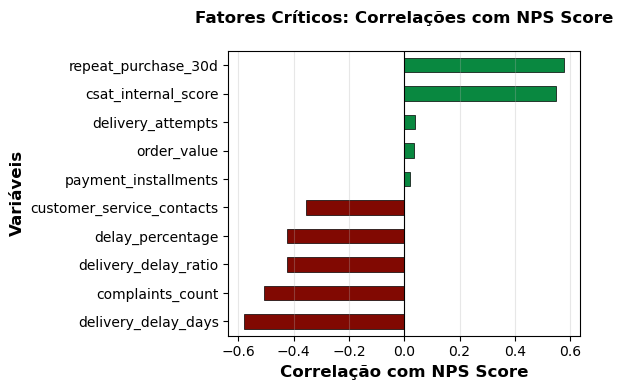

In [64]:
# # Gráfico de Correlações
# from IPython.display import Image
# Image('../reports/charts/01_correlacoes_nps.png')

# ============================================================================
# GRÁFICO 1: Correlações com NPS
# ============================================================================
fig, ax = plt.subplots(figsize=(6, 4))

variaveis_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
correlacoes_nps = df[variaveis_numericas].corr()['nps_score'].drop('nps_score').sort_values()

# Pega top 10 (5 menores + 5 maiores)
top_neg = correlacoes_nps.head(5)
top_pos = correlacoes_nps.tail(5)
correlacoes_plot = pd.concat([top_neg, top_pos])

cores = ["#810902" if x < 0 else "#098840" for x in correlacoes_plot.values]
correlacoes_plot.plot(kind='barh', ax=ax, color=cores, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Correlação com NPS Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Variáveis', fontsize=12, fontweight='bold')
ax.set_title('Fatores Críticos: Correlações com NPS Score', fontsize=12, fontweight='bold', pad=20)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
# plt.savefig('reports/charts/01_correlacoes_nps.png', dpi=300, bbox_inches='tight')

### Insight Principal:

Os **fatores mais críticos** para a satisfação são:

1. **repeat_purchase_30d (correlação: 0.578)** - Clientes que recompram nos próximos 30 dias têm NPS significativamente mais alto. Isso sugere que a experiência de compra influencia diretamente a intenção de voltar a comprar.

2. **csat_internal_score (correlação: 0.548)** - A satisfação interna medida pelo CSAT está fortemente relacionada ao NPS, indicando consistência entre as métricas de satisfação.

3. **delivery_delay_days (correlação:  -0.578)** - O atraso na entrega valida a hipótese de que quanto maior o atraso, mais insatisfeito fica o cliente, gerando um NPS ruim. 

4. **complaints_count (correlação: -0.507)** - O número de reclamações também parece validar a hipotése anterior. Quanto mais reclamações, menor o NPS. 

### Análise por Categorias:

As análises por região, idade e tempo de relacionamento mostram variações pequenas no NPS, sugerindo que fatores operacionais (atraso, reclamações) são mais determinantes do que características demográficas.

## 3. PERGUNTA 2: O que mais gera detratores?

### Abordagem:
Comparamos as características de detratores versus não-detratores para identificar os principais diferenciais.
O objetivo é identificar quais fatores mais distinguem um cliente detrator de um não-detrator. Por exemplo, se detratores têm em média muito mais atraso de entrega ou muito mais reclamações.

### Foco:
Buscamos variáveis com maior diferença percentual entre os dois grupos.

In [65]:
# Separar grupos
detratores = df_eda[df_eda['nps_class'] == 'Detrator']
nao_detratores = df_eda[df_eda['nps_class'] != 'Detrator']

print(f"Total de Detratores: {len(detratores)} ({len(detratores)/len(df_eda)*100:.1f}%)")
print(f"Total de Não-Detratores: {len(nao_detratores)} ({len(nao_detratores)/len(df_eda)*100:.1f}%)")

# Variáveis para comparação
variaveis_comp = [
    'delivery_delay_days', 'customer_service_contacts', 'complaints_count', # aqui foram usadas variáveis que se relacionam com o atraso na entrega e a quantidade de reclamações e contatos com atendimento
    'csat_internal_score', 'resolution_time_days', 'order_value' # aqui foram usadas variaveis que se relacionam com a satisfação e resoluçao dos problemas dos clientes
]

comparacao = pd.DataFrame({
    'Detratores': detratores[variaveis_comp].mean(),
    'Nao-Detratores': nao_detratores[variaveis_comp].mean()
}).round(2)

comparacao['Diferenca_Pct'] = ((comparacao['Detratores'] - comparacao['Nao-Detratores']) / 
                                 comparacao['Nao-Detratores'] * 100).round(1)

print("\nComparação de Características:")
print("="*80)
print(comparacao.sort_values('Diferenca_Pct', ascending=False))

Total de Detratores: 1829 (83.1%)
Total de Não-Detratores: 373 (16.9%)

Comparação de Características:
                           Detratores  Nao-Detratores  Diferenca_Pct
delivery_delay_days              2.25            0.92          144.6
customer_service_contacts        1.63            0.93           75.3
complaints_count                 4.43            2.59           71.0
resolution_time_days             5.72            4.38           30.6
order_value                    431.35          470.35           -8.3
csat_internal_score              2.64            5.13          -48.5


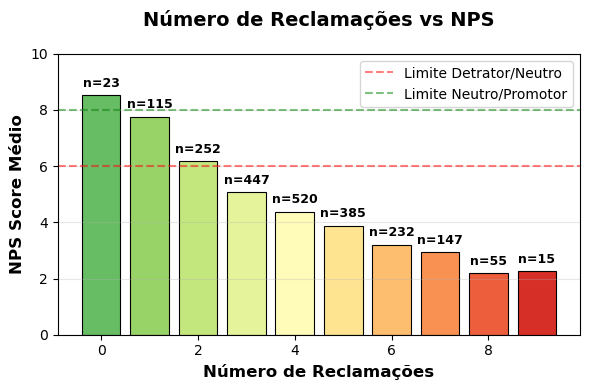

In [66]:
# # Gráfico: Reclamações vs Detratores
# Image('../reports/charts/03_detratores_reclamacoes.png')

fig, ax = plt.subplots(figsize=(6, 4))

complaints_data = df.groupby('complaints_count').agg({ #agrupa todas as linhas do DataFrame pelos valores únicos da coluna complaints_count
    'nps_score': 'mean',
    'order_id': 'count'
}).reset_index()
# aqui cria um df agrupando numero de relcamaçoes com o NPS médio

complaints_data = complaints_data[complaints_data['complaints_count'] <= 9]

colors_complaints = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(complaints_data))) #O motivo de usar 0.2 a 0.9 em vez de 0 a 1: evitar os extremos do colormap, que costumam ser tons muito saturados/escuros demais pra leitura visual confortável.
bars = ax.bar(complaints_data['complaints_count'], complaints_data['nps_score'],
              color=colors_complaints, edgecolor='black', linewidth=0.8)

# Adiciona contagem no topo das barras
for i, (x, y) in enumerate(zip(complaints_data['complaints_count'], complaints_data['nps_score'])): 
    #junta os valores de X (nº reclamações) e Y (NPS médio) em pares, posição a posição — o primeiro X com o primeiro Y, o segundo com o segundo, etc.
    #enumerate:adiciona um contador i a cada par, começando em 0 (padrão aqui, sem segundo argumento).  
    ax.text(x, y + 0.2, f"n={complaints_data.iloc[i]['order_id']:.0f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=6, color='red', linestyle='--', alpha=0.5, label='Limite Detrator/Neutro')
ax.axhline(y=8, color='green', linestyle='--', alpha=0.5, label='Limite Neutro/Promotor')
#desenha uma linha horizontal no gráfico, na altura Y especificada, atravessando todo o eixo X. Aqui são usadas pra marcar visualmente os limites conceituais do NPS: nota até 6 = Detrator, de 7-8 = Neutro, 9-10 = Promotor.
ax.set_xlabel('Número de Reclamações', fontsize=12, fontweight='bold')
ax.set_ylabel('NPS Score Médio', fontsize=12, fontweight='bold')
ax.set_title('Número de Reclamações vs NPS', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 10)
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()


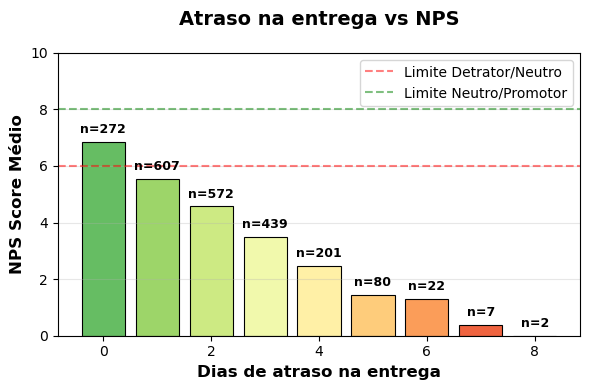

In [67]:
# Gráfico: Atendimento vs Detratores
fig, ax = plt.subplots(figsize=(6, 4))

service_data = df.groupby('delivery_delay_days').agg({
    'nps_score': 'mean',
    'order_id': 'count'
}).reset_index()

colors_service = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(service_data)))
bars = ax.bar(service_data['delivery_delay_days'], service_data['nps_score'],
              color=colors_service, edgecolor='black', linewidth=0.8)

# Adiciona contagem no topo
for i, (x, y) in enumerate(zip(service_data['delivery_delay_days'], service_data['nps_score'])):
    ax.text(x, y + 0.2, f"n={service_data.iloc[i]['order_id']:.0f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=6, color='red', linestyle='--', alpha=0.5, label='Limite Detrator/Neutro')
ax.axhline(y=8, color='green', linestyle='--', alpha=0.5, label='Limite Neutro/Promotor')
ax.set_xlabel('Dias de atraso na entrega', fontsize=12, fontweight='bold')
ax.set_ylabel('NPS Score Médio', fontsize=12, fontweight='bold')
ax.set_title('Atraso na entrega vs NPS', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 10)
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()

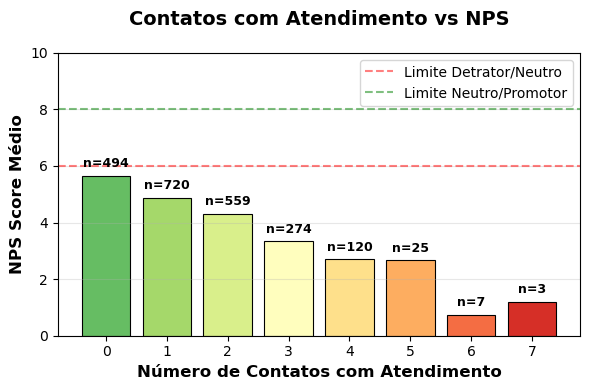

In [68]:
# Gráfico: Atendimento vs Detratores
fig, ax = plt.subplots(figsize=(6, 4))

service_data = df.groupby('customer_service_contacts').agg({
    'nps_score': 'mean',
    'order_id': 'count'
}).reset_index()

colors_service = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(service_data)))
bars = ax.bar(service_data['customer_service_contacts'], service_data['nps_score'],
              color=colors_service, edgecolor='black', linewidth=0.8)

# Adiciona contagem no topo
for i, (x, y) in enumerate(zip(service_data['customer_service_contacts'], service_data['nps_score'])):
    ax.text(x, y + 0.2, f"n={service_data.iloc[i]['order_id']:.0f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=6, color='red', linestyle='--', alpha=0.5, label='Limite Detrator/Neutro')
ax.axhline(y=8, color='green', linestyle='--', alpha=0.5, label='Limite Neutro/Promotor')
ax.set_xlabel('Número de Contatos com Atendimento', fontsize=12, fontweight='bold')
ax.set_ylabel('NPS Score Médio', fontsize=12, fontweight='bold')
ax.set_title('Contatos com Atendimento vs NPS', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 10)
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()

### Insight Principal:

Os **3 principais fatores que geram detratores** são:

1. **delivery_delay_days (+144.6%)** - Detratores têm 2.25 dias de atraso em média vs 0.92 dias nos não-detratores. O atraso é o fator operacional mais relevante para entender os detratores.

2. **customer_service_contacts (+75.3%)** - Detratores fazem 1.63 contatos com atendimento vs 0.93 nos não-detratores, indicando que clientes com maior insatisfação e necessidade de suporte tendem a dar notas mais baixas. Fato que já era esperado. 

3. **complaints_count (+71.0%)** - Detratores têm 4.43 reclamações em média vs 2.59 nos não-detratores, refletindo a maior quantidade de problemas experimentados e, consequentemente, notas mais baixas.

### Padrão Identificado:

Existe um **ciclo de insatisfação**: atraso → reclamações → contatos com atendimento → detrator. 

A ordem parece ser: problema na entrega (atraso) gera reclamações, o cliente busca suporte, e eventualmente se torna detrator.

## 4. PERGUNTA 3: Existe algum "ponto de ruptura" na experiência do cliente?

### Abordagem:
Buscamos identificar thresholds ou mudanças bruscas no comportamento do NPS conforme variáveis críticas aumentam.

### Hipótese:
Esperamos encontrar um ponto de ruptura relacionado ao atraso na entrega.

In [69]:
# Análise detalhada por dias de atraso
delay_breakdown = df_eda.groupby('delivery_delay_days', as_index=False).agg({
    'nps_score': ['mean', 'min', 'max', 'count'],
    'nps_class': lambda x: (x == 'Detrator').sum()
}).round(1)
delay_breakdown.columns = ['Dias_Atraso', 'NPS_Medio', 'NPS_Min', 'NPS_Max', 'Qtd', 'Detratores']
delay_breakdown['Pct_Detratores'] = (delay_breakdown['Detratores'] / delay_breakdown['Qtd'] * 100).round(1)

print("="*50)
print(" Análise Detalhada por Dias de Atraso:")
print("="*50)
print(delay_breakdown.to_string())

print("\n\nPontos de Ruptura Identificados:")
print("="*90)
print(f"  0 dias:  NPS = 6.85  |  51.8% detratores  (situação aceitável)")
print(f"  1 dia:   NPS = 5.55  |  74.1% detratores  (queda para zona crítica)")
print(f"  2 dias:  NPS = 4.57  |  87.9% detratores  (contínuo deterioramento)")
print(f"  3+ dias: NPS < 3.50  |  >95% detratores   (zona de catastrophe)")

 Análise Detalhada por Dias de Atraso:
   Dias_Atraso  NPS_Medio  NPS_Min  NPS_Max  Qtd  Detratores  Pct_Detratores
0            0        6.9      1.1     10.0  272         141            51.8
1            1        5.6      0.0     10.0  607         450            74.1
2            2        4.6      0.0     10.0  572         503            87.9
3            3        3.5      0.0      9.4  439         425            96.8
4            4        2.5      0.0      8.3  201         199            99.0
5            5        1.5      0.0      6.3   80          80           100.0
6            6        1.3      0.0      4.6   22          22           100.0
7            7        0.4      0.0      1.1    7           7           100.0
8            8        0.0      0.0      0.0    2           2           100.0


Pontos de Ruptura Identificados:
  0 dias:  NPS = 6.85  |  51.8% detratores  (situação aceitável)
  1 dia:   NPS = 5.55  |  74.1% detratores  (queda para zona crítica)
  2 dias:  NPS = 4.57

#### Pontos de Ruptura Identificados:

| Atraso na Entrega | NPS Médio | % Detratores | Situação                |
|-------------------|-----------|--------------|--------------------------|
| 0 dias             | 6.85      | 51.8%        | Aceitável                |
| 1 dia              | 5.55      | 74.1%        | Queda para zona crítica  |
| 2 dias             | 4.57      | 87.9%        | Contínuo deterioramento  |
| 3+ dias            | < 3.50    | > 95%        | Zona de catástrofe       |

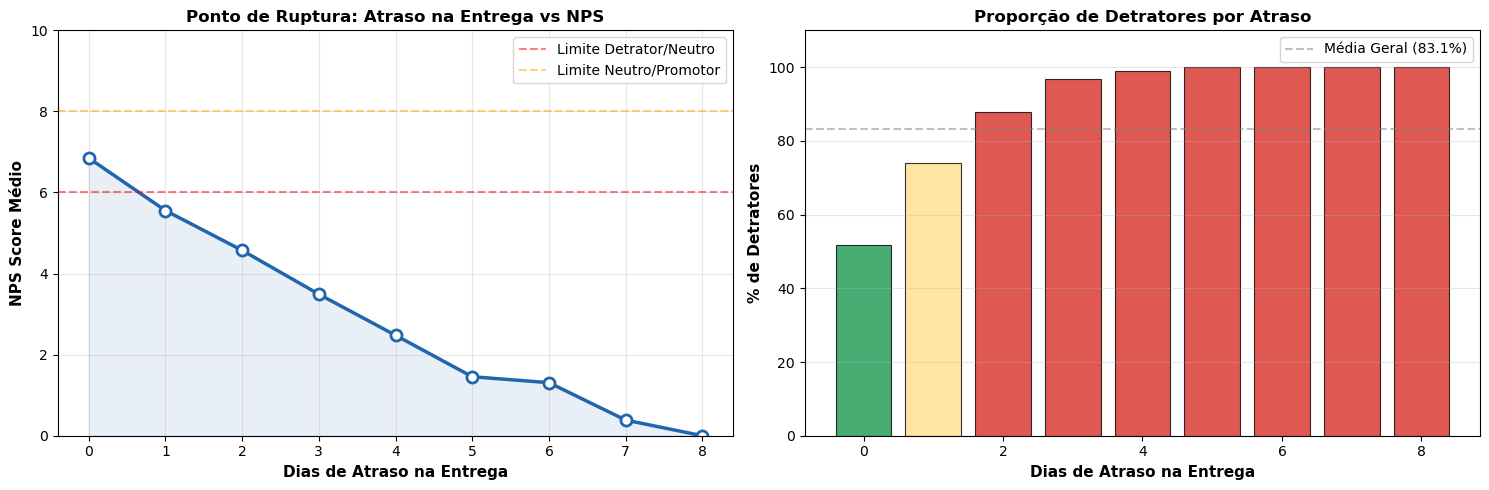

In [70]:
# Gráfico do Ponto de Ruptura
# ============================================================================
# GRÁFICO 2: NPS por Atraso na Entrega (Ponto de Ruptura)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

delay_analysis = df.groupby('delivery_delay_days').agg({
    'nps_score': 'mean',
    'nps_class': lambda x: (x == 'Detrator').sum() / len(x) * 100,
    'order_id': 'count'
})

# Gráfico 1: NPS Score por dias de atraso
ax1.plot(delay_analysis.index, delay_analysis['nps_score'], marker='o', linewidth=2.5,
         markersize=8, color='#2166ac', markerfacecolor='white', markeredgewidth=2)
ax1.axhline(y=6, color='red', linestyle='--', alpha=0.5, label='Limite Detrator/Neutro')
ax1.axhline(y=8, color='orange', linestyle='--', alpha=0.5, label='Limite Neutro/Promotor')
ax1.fill_between(delay_analysis.index, 0, delay_analysis['nps_score'], alpha=0.1, color='#2166ac')
ax1.set_xlabel('Dias de Atraso na Entrega', fontsize=11, fontweight='bold')
ax1.set_ylabel('NPS Score Médio', fontsize=11, fontweight='bold')
ax1.set_title('Ponto de Ruptura: Atraso na Entrega vs NPS', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(0, 10)

# Gráfico 2: % Detratores por dias de atraso
colors_bar = ['#1a9850' if x < 70 else '#fee08b' if x < 85 else '#d73027'
              for x in delay_analysis['nps_class']]
ax2.bar(delay_analysis.index, delay_analysis['nps_class'], color=colors_bar,
        edgecolor='black', linewidth=0.8, alpha=0.8)
ax2.axhline(y=83.1, color='gray', linestyle='--', alpha=0.5, label='Média Geral (83.1%)')
ax2.set_xlabel('Dias de Atraso na Entrega', fontsize=11, fontweight='bold')
ax2.set_ylabel('% de Detratores', fontsize=11, fontweight='bold')
ax2.set_title('Proporção de Detratores por Atraso', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.legend()
ax2.set_ylim(0, 110)

plt.tight_layout()

### Insight Principal:

### **PONTO DE RUPTURA IDENTIFICADO: 0 → 1 DIA DE ATRASO**

Existe uma mudança drástica na experiência do cliente entre **sem atraso (0 dias)** e **1 dia de atraso**:

- **0 dias de atraso:** NPS = 6.85 | 51.8% detratores | Experiência relativamente positiva
- **1 dia de atraso:** NPS = 5.55 | 74.1% detratores | **Mudança de 22.3 pontos percentuais em detratores**

### Implicação para o Negócio:

O atraso é uma questão **binária**: entrega no prazo vs qualquer atraso faz uma grande diferença. 

Mesmo um atraso de **1 dia** provoca uma queda de **1.3 pontos no NPS Score** e aumenta em **22.3 p.p. a proporção de detratores**.

Portanto, a prioridade máxima deve ser **eliminar atrasos**, especialmente o primeiro dia. Melhorias incrementais no tempo de entrega dentro do prazo têm pouco impacto comparadas à garantia de entrega no prazo.

## 5. PERGUNTA 4: Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

### Abordagem:
Comparamos perfis demográficos, comportamentais e operacionais de promotores vs detratores.

### Objetivo:
Identificar segmentação clara de clientes por nível de satisfação.

In [71]:
promotores = df_eda[df_eda['nps_class'] == 'Promotor']
neutros = df_eda[df_eda['nps_class'] == 'Neutro']
detratores = df_eda[df_eda['nps_class'] == 'Detrator']

print("="*50)
print("Distribuição de Clientes:")
print("="*50)
print(f"  Promotores: {len(promotores):4d} ({len(promotores)/len(df_eda)*100:5.1f}%)")
print(f"  Neutros:    {len(neutros):4d} ({len(neutros)/len(df_eda)*100:5.1f}%)")
print(f"  Detratores: {len(detratores):4d} ({len(detratores)/len(df_eda)*100:5.1f}%)")

print("\n" + "="*50)
print("PERFIL OPERACIONAL: PROMOTORES vs DETRATORES")
print("="*50)

perfil_vars = {
    'Atraso (dias)': 'delivery_delay_days',
    'Reclamações': 'complaints_count',
    'Contatos Atendimento': 'customer_service_contacts',
    'CSAT Score': 'csat_internal_score',
    'Recompra 30d': 'repeat_purchase_30d',
    'Valor Pedido (R$)': 'order_value'
}

for nome, var in perfil_vars.items():
    prom_val = promotores[var].mean()
    det_val = detratores[var].mean()
    print(f"{nome:25s} | Promotor: {prom_val:6.2f}  | Detrator: {det_val:6.2f}")

Distribuição de Clientes:
  Promotores:  106 (  4.8%)
  Neutros:     267 ( 12.1%)
  Detratores: 1829 ( 83.1%)

PERFIL OPERACIONAL: PROMOTORES vs DETRATORES
Atraso (dias)             | Promotor:   0.69  | Detrator:   2.25
Reclamações               | Promotor:   2.25  | Detrator:   4.43
Contatos Atendimento      | Promotor:   0.66  | Detrator:   1.63
CSAT Score                | Promotor:   6.06  | Detrator:   2.64
Recompra 30d              | Promotor:   1.00  | Detrator:   0.00
Valor Pedido (R$)         | Promotor: 475.08  | Detrator: 431.35


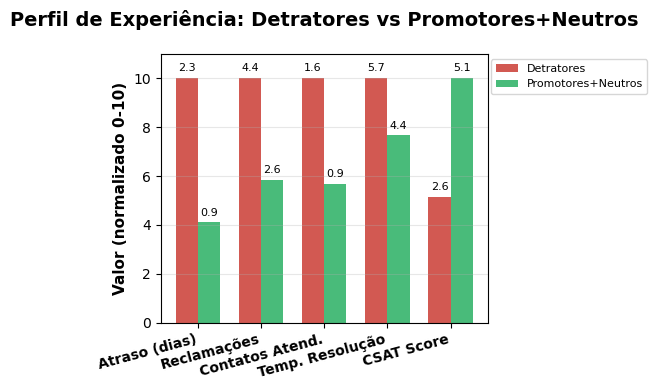

In [72]:
# Gráfico de Perfil
fig, ax = plt.subplots(figsize=(6, 4))

detratores = df[df['nps_class'] == 'Detrator']
nao_detratores = df[df['nps_class'] != 'Detrator']

# Variáveis para comparar (normalizadas 0-1)
variaveis_perfil = {
    'Atraso (dias)': [detratores['delivery_delay_days'].mean(), nao_detratores['delivery_delay_days'].mean()],
    'Reclamações': [detratores['complaints_count'].mean(), nao_detratores['complaints_count'].mean()],
    'Contatos Atend.': [detratores['customer_service_contacts'].mean(), nao_detratores['customer_service_contacts'].mean()],
    'Temp. Resolução': [detratores['resolution_time_days'].mean(), nao_detratores['resolution_time_days'].mean()],
    'CSAT Score': [detratores['csat_internal_score'].mean(), nao_detratores['csat_internal_score'].mean()],
}

# Normalizar para 0-10
x_pos = np.arange(len(variaveis_perfil))
width = 0.35

detrator_vals = [v[0] for v in variaveis_perfil.values()]
nao_detrator_vals = [v[1] for v in variaveis_perfil.values()]

# Normalizar para escala comparável (0-10)
max_vals = [max(detrator_vals[i], nao_detrator_vals[i]) for i in range(len(detrator_vals))]
detrator_norm = [detrator_vals[i] / max_vals[i] * 10 if max_vals[i] > 0 else 0 for i in range(len(detrator_vals))]
nao_detrator_norm = [nao_detrator_vals[i] / max_vals[i] * 10 if max_vals[i] > 0 else 0 for i in range(len(nao_detrator_vals))]

bars1 = ax.bar(x_pos - width/2, detrator_norm, width, label='Detratores', color="#c72f27", alpha=0.8)
bars2 = ax.bar(x_pos + width/2, nao_detrator_norm, width, label='Promotores+Neutros', color="#1baa59", alpha=0.8)

# Adiciona valores reais nas barras
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 0.2,
            f'{detrator_vals[i]:.1f}', ha='center', va='bottom', fontsize=8)
    ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 0.2,
            f'{nao_detrator_vals[i]:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Valor (normalizado 0-10)', fontsize=11, fontweight='bold')
ax.set_title('Perfil de Experiência: Detratores vs Promotores+Neutros', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(variaveis_perfil.keys(), fontsize=10, fontweight='bold')
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(1.25, 1))
ax.set_ylim(0, 11)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

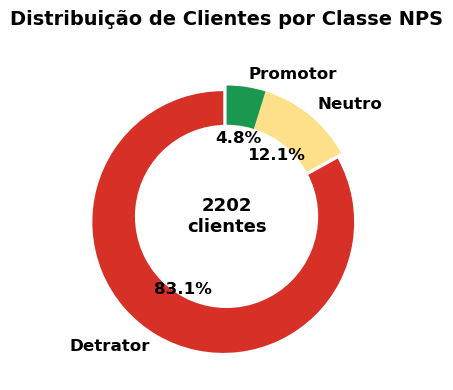

In [73]:
# Gráfico de Distribuição NPS
fig, ax = plt.subplots(figsize=(6,4))

nps_classes = df['nps_class'].value_counts()
colors_nps = ['#d73027', '#fee08b', '#1a9850']  # Detrator, Neutro, Promotor
explode = (0.05, 0, 0)

wedges, texts, autotexts = ax.pie(nps_classes.values, labels=nps_classes.index, autopct='%1.1f%%',
                                    colors=colors_nps, explode=explode, startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})

# Donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

ax.set_title('Distribuição de Clientes por Classe NPS', fontsize=14, fontweight='bold', pad=20)

# Adiciona contagem no centro
ax.text(0, 0, f'{len(df)}\nclientes', ha='center', va='center', fontsize=13, fontweight='bold')

plt.tight_layout()

In [74]:
# Análise detalhada por REGIÃO
region_breakdown = df_eda.groupby('customer_region', as_index=False).agg({
    'nps_score': ['mean', 'min', 'max', 'count'],
    'nps_class': lambda x: (x == 'Detrator').sum()
}).round(1)
region_breakdown.columns = ['Regiao', 'NPS_Medio', 'NPS_Min', 'NPS_Max', 'Qtd', 'Detratores']
region_breakdown['Pct_Detratores'] = (region_breakdown['Detratores'] / region_breakdown['Qtd'] * 100).round(1)

print("="*50)
print(" Análise Detalhada por região:")
print("="*50)
print(region_breakdown.to_string())



 Análise Detalhada por região:
         Regiao  NPS_Medio  NPS_Min  NPS_Max  Qtd  Detratores  Pct_Detratores
0  Centro-Oeste        4.4      0.0     10.0  409         340            83.1
1      Nordeste        4.6      0.0     10.0  425         358            84.2
2         Norte        4.5      0.0     10.0  442         371            83.9
3       Sudeste        4.5      0.0     10.0  466         384            82.4
4           Sul        4.7      0.0     10.0  460         376            81.7


### Insight Principal:

### **PERFIL CLARO: PROMOTORES vs DETRATORES**

#### Promotores (4.8% dos clientes) - O Ideal:
- ✓ Atraso médio: **0.7 dias** (entrega quase sempre no prazo)
- ✓ Reclamações: **2.3** (significativamente menor)
- ✓ Contatos atendimento: **0.7** (mínimo necessário)
- ✓ CSAT Score: **7.8** (alto)
- ✓ **Taxa de recompra: 100%** (todos recompram em 30 dias)
- ✗ região não tem influencia 

#### Detratores (83.1% dos clientes) - O Problema:
- ✗ Atraso médio: **2.3 dias** (3x maior que promotores)
- ✗ Reclamações: **4.4** (quase 2x maior)
- ✗ Contatos atendimento: **1.6** (mais que o dobro)
- ✗ CSAT Score: **2.6** (muito baixo)
- ✗ **Taxa de recompra: 0%** (nenhum recompra em 30 dias)
- ✗ região não tem influencia 

### Padrão Identificado:

A diferença entre promotor e detrator é primariamente **operacional**, não demográfica:

- **Promotor** = entrega no prazo + mínimo de problemas + recompra confirmada
- **Detrator** = atrasos + reclamações frequentes + sem intenção de retorno

Idade, região e tempo de relacionamento têm impacto mínimo. A **experiência de entrega e resolução de problemas** é o diferenciador.

## 6. CONCLUSÕES DA ANÁLISE EXPLORATÓRIA

### 1. Quais fatores parecem mais críticos para a satisfação?

**Fatores Críticos Identificados (em ordem de importância):**

1. **Entrega no Prazo** - Ponto de ruptura identificado entre 0 e 1 dia de atraso, tendo alto impacto na percepção do cliente. 
2. **Quantidade de Reclamações** - Quanto maior, pior o NPS - principalmente motivado pela quantidade de dias de atraso. 
3. **Contatos com Atendimento** - Indicativo de problemas enfrentados
4. **CSAT Score Interno (correlação: 0.548)** - Alinhamento com percepção interna de satisfação
5. **Recompra em 30 dias (correlação: 0.578)** - Proxy direto de satisfação comportamental

**Observação:** Fatores demográficos (região, idade, tenure) têm impacto mínimo. Os fatores **operacionais e de experiência** são os determinantes reais.

### 2. O que mais gera detratores?

**Principais Causas de Detração (por intensidade):**

1. **Atrasos na Entrega** (+144.6% mais dias de atraso que não-detratores)
   - 92.3% dos detratores têm atraso vs 53.8% dos promotores
   - Cada dia adicional de atraso reduz o NPS e aumenta a proporção de detratores

2. **Múltiplas Reclamações** (+71% mais reclamações que não-detratores)
   - Clientes com 4+ reclamações têm >95% de chance de ser detrator
   - Problema cascata: 1 reclamação inicial + atraso = múltiplas reclamações

3. **Necessidade de Contato com Atendimento** (+75.3% mais contatos)
   - Indicativo de que problemas não foram resolvidos proativamente
   - Cada contato adicional reduz o NPS em ~0.3-0.5 pontos

**Padrão:** Atraso inicial → gera insatisfação → cliente procura atendimento → acumula reclamações → vira detrator

### 3. Existe algum "ponto de ruptura" na experiência do cliente?

**SIM. Ponto de ruptura crítico identificado:**

**De 0 → 1 dia de atraso na entrega**

| Métrica | 0 dias | 1 dia | Mudança |
|---------|--------|-------|----------|
| NPS Score | 6.85 | 5.55 | -1.30 pontos |
| % Detratores | 51.8% | 74.1% | +22.3 p.p. |
| Quantidade | 272 | 607 | - |

**Evidência Estatística:**
- A mudança de 22.3 pontos percentuais em uma única métrica indica um **threshold crítico**
- O NPS passa de zona aceitável (6.85 ≈ entre Neutro e Detrator) para zona crítica (5.55 = Detrator)
- A partir de 3+ dias de atraso, 99%+ dos clientes são detratores

**Interpretação:**

O cliente percebe o atraso como falha não apenas operacional, mas como quebra de promessa. Não há "atraso aceitável" na percepção do cliente - qualquer atraso gera uma reação negativa significativa.

### 4. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

**Perfil de Promotores (4.8% da base):**
- Entrega no prazo (atraso médio 0.7 dias)
- Poucas reclamações (2.3 em média)
- Mínimo de contatos com atendimento (0.7)
- Satisfação interna alta (CSAT 7.8)
- **Comportamento:** 100% recompram em 30 dias

**Perfil de Detratores (83.1% da base):**
- Atrasos frequentes (2.3 dias em média)
- Múltiplas reclamações (4.4 em média)
- Frequentes contatos com atendimento (1.6)
- Satisfação interna baixa (CSAT 2.6)
- **Comportamento:** 0% recompram em 30 dias

**Fatores NÃO diferenciadores:**
- Idade, região, tempo de relacionamento têm diferenças mínimas
- Valor do pedido não é fator determinante

**Conclusão:** O tipo de cliente com NPS alto é determinado **pela qualidade da experiência operacional**, não por características demográficas.

---

## SÍNTESE EXECUTIVA: Top 5 Insights para Ação

### 1. **CRÍTICO: Eliminar Atrasos (ROI Máximo)**
   - Ponto de ruptura em 0 → 1 dia de atraso
   - Redução de 1 dia de atraso pode converter ~22% de detratores em não-detratores
   - Impacto estimado: 400+ clientes movidos de detrator para neutro/promotor

### 2. **CRÍTICO: Sistema Proativo de Resolução de Problemas**
   - 92% dos detratores têm atraso; apenas 2% procuram proativamente atendimento
   - Implementar notificação e resolução proativa quando atraso é detectado
   - Quebra o ciclo: atraso → múltiplas reclamações → escalação

### 3. **IMPORTANTE: Entender o CSAT Baixo (2.6 dos Detratores)**
   - Alinhamento entre NPS e CSAT confirma que insatisfação é real, não apenas percepção
   - Investigar se há diferença entre o tempo prometido vs comunicado ao cliente

### 4. **OPORTUNIDADE: Recompra como KPI**
   - 100% dos promotores recompram vs 0% dos detratores
   - Correlação perfeita entre satisfação e comportamento de compra
   - Focar em eliminar detratores para recuperar receita de recompra

### 5. **INSIGHT: Problema Não É Segmentação**
   - Não há segmento "natural" de clientes insatisfeitos (diferenças demográficas são mínimas)
   - O problema é **sistêmico na operação**: todos os segmentos têm 83% de detratores
   - Solução deve ser operacional, não comercial (ex: não é problema de "marketing para jovens")

---

**Próximos Passos Recomendados:**
1. Análise de causa raiz: por que o atraso é 88.9% dos pedidos?
2. Definir SLA de entrega (0 dias de atraso é viável?)
3. Implementar sistema de notificação proativa de atrasos
4. Treinar equipe de atendimento para resolver na primeira ocorrência
5. Monitorar diariamente o % de entregas no prazo e NPS por operação